# Anime Recommendation System - SVD Model and Evaluation

## tl;dr

In the verified baseline run, deterministic sampling and k-core filtering retained 952,497 explicit ratings from 41,370 users across 5,985 anime. The fixed 50-factor SVD baseline achieved outer-holdout RMSE 1.2632 and MAE 0.9625; held-out observed-item Precision@10 was 0.6386 and Recall@10 was 0.8255 across 4,802 eligible users. Re-run the notebook after changing inputs or configuration; the runtime-generated summary near the end is the authoritative source for the current values.

## Context, Inputs, and Outputs

Notebook 01 prepares explicit ratings. This notebook first looks for the two cleaned files uploaded to the Colab server root, then falls back to this project's cleaned_data/ directory. A rating of -1 is not a score and is invalid for SVD. Sampling is not the full dataset, and metadata is display-only.

Inputs: cleaned_data/ratings_clean.csv and cleaned_data/anime_clean.csv.

Outputs: outputs/top_10_recommendations.csv, outputs/model_evaluation_metrics.csv, and three PNGs in outputs/figures/.

## How to Read This Notebook

Evaluation and serving use separate fitted models: one protects honest holdout metrics, and one uses all model data for recommendation serving.

    Cleaned explicit ratings
      -> sample and k-core filter
      -> outer train/test split
      -> evaluate SVD on held-out ratings
      -> refit SVD on all model data
      -> rank unseen candidates and export Top-10

## Setup

The constants, paths, and deterministic seed make the experiment resource-aware and reproducible from either the project root or notebooks/.

### Colab Dependency

On a fresh Colab runtime, install Surprise only when it is unavailable. The remaining cells use the same package whether it was already installed or added here.

In [1]:
try:
    import surprise
except ImportError:
    %pip install -q scikit-surprise

### Imports, Constants, and Paths

Resolve the cleaned-data location before reading it: prefer a complete pair uploaded to the Colab server root, then explicitly use the local cleaned_data/ directory.

In [2]:
from collections import defaultdict
from pathlib import Path
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split

SEED = 42
RATING_MIN, RATING_MAX = 1, 10
MAX_RATINGS = 1_000_000
MIN_USER_RATINGS = MIN_ITEM_RATINGS = 5
MAX_CORE_FILTER_PASSES = 10
TEST_SIZE = 0.20
K = 10
POSITIVE_RATING = 8
N_EXAMPLE_USERS = 7
MIN_RATINGS_FOR_EXAMPLE_USER = 20
EXAMPLE_USER_IDS = None

current_directory = Path.cwd()
data_locations = [(Path("/content"), "Colab server root")]
for local_root in (current_directory, current_directory.parent):
    data_locations.append((local_root / "cleaned_data", "local cleaned_data directory"))

for data_directory, data_source in data_locations:
    ratings_candidate = data_directory / "ratings_clean.csv"
    anime_candidate = data_directory / "anime_clean.csv"
    if ratings_candidate.exists() and anime_candidate.exists():
        CLEANED_DATA_DIR = data_directory
        RATINGS_PATH, ANIME_PATH = ratings_candidate, anime_candidate
        PROJECT_ROOT = data_directory if data_source == "Colab server root" else data_directory.parent
        break
else:
    attempted_locations = "\n".join(str(directory.resolve()) for directory, _ in data_locations)
    raise FileNotFoundError(
        "Could not find both cleaned input files. Checked the Colab server root first and then local cleaned_data/ directories:\n"
        f"{attempted_locations}"
    )

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Cleaned-data source: {data_source} ({CLEANED_DATA_DIR.resolve()})")

Project root: C:\Users\Quoc\Desktop\DTU\ML Large Data\Anime Recommend
Cleaned-data source: local cleaned_data directory (C:\Users\Quoc\Desktop\DTU\ML Large Data\Anime Recommend\cleaned_data)


Small helpers centralize schema validation, matrix audit statistics, iterative k-core filtering, held-out ranking metrics, chart export, and safe metadata display.

In [3]:
def require_columns(df, required_columns, dataset_name):
    "Raise an English error when a required schema column is absent."
    missing = sorted(set(required_columns) - set(df.columns))
    if missing:
        raise ValueError(f"{dataset_name} is missing required columns: {missing}. Available columns: {df.columns.tolist()}")

def matrix_summary(ratings, stage):
    "Return one audit row for a sparse explicit-rating matrix."
    users = ratings.groupby("user_id").size()
    items = ratings.groupby("anime_id").size()
    n_users, n_items = len(users), len(items)
    return pd.DataFrame([{
        "stage": stage, "interactions": len(ratings), "users": n_users, "anime": n_items,
        "density": len(ratings) / (n_users * n_items) if n_users and n_items else np.nan,
        "rating_mean": ratings.rating.mean(), "rating_median": ratings.rating.median(),
        "user_interactions_min": users.min(), "user_interactions_median": users.median(),
        "user_interactions_p90": users.quantile(.90), "item_interactions_min": items.min(),
        "item_interactions_median": items.median(), "item_interactions_p90": items.quantile(.90),
    }])

def iterative_k_core_filter(ratings, min_user_ratings, min_item_ratings, max_passes):
    "Iteratively keep users and anime satisfying interaction thresholds."
    filtered, audit = ratings.copy(), []
    for pass_number in range(1, max_passes + 1):
        before = len(filtered)
        user_counts = filtered.groupby("user_id").size()
        filtered = filtered[filtered.user_id.isin(user_counts[user_counts >= min_user_ratings].index)].copy()
        item_counts = filtered.groupby("anime_id").size()
        filtered = filtered[filtered.anime_id.isin(item_counts[item_counts >= min_item_ratings].index)].copy()
        row = matrix_summary(filtered, f"K-core pass {pass_number}").iloc[0].to_dict()
        row.update({"pass": pass_number, "rows_removed": before - len(filtered)})
        audit.append(row)
        if len(filtered) == before:
            return filtered, pd.DataFrame(audit)
    raise RuntimeError(f"K-core filtering did not converge within {max_passes} passes.")

def precision_recall_at_k(predictions, k, positive_rating):
    "Macro-average held-out observed-item Precision@K and Recall@K."
    by_user = defaultdict(list)
    for prediction in predictions:
        by_user[str(prediction.uid)].append((str(prediction.iid), float(prediction.r_ui), float(prediction.est)))
    precisions, recalls = [], []
    fewer_than_k, no_relevant = 0, 0
    for rows in by_user.values():
        if len(rows) < k:
            fewer_than_k += 1
            continue
        relevant = sum(actual >= positive_rating for _, actual, _ in rows)
        if not relevant:
            no_relevant += 1
            continue
        top_k = sorted(rows, key=lambda row: (-row[2], row[0]))[:k]
        hits = sum(actual >= positive_rating for _, actual, _ in top_k)
        precisions.append(hits / k)
        recalls.append(hits / relevant)
    if not precisions:
        raise ValueError("No eligible users were available for held-out ranking evaluation.")
    return {
        "precision_at_k": float(np.mean(precisions)), "recall_at_k": float(np.mean(recalls)),
        "eligible_users": len(precisions), "users_with_fewer_than_k_test_items": fewer_than_k,
        "users_without_relevant_test_item": no_relevant, "total_test_users": len(by_user),
    }

def save_figure(filename):
    "Save the current figure as a 300-dpi PNG and display it."
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return path

def metadata_for_display(anime_df):
    "Return display-safe metadata without changing the source frame."
    result = anime_df.copy()
    result["name"] = result["name"].astype("string")
    result["genre"] = result["genre"].astype("string")
    return result

## Load and Validate Prepared Data

## Recommendation Task and Data Boundaries

One row represents one user's explicit 1--10 score for one anime. A value of -1 means watched but not scored and is excluded. Anime metadata is only for readable output, never SVD training.

ratings_clean is the cleaned source. ratings_model is a sampled and filtered model-specific dataset, not the full cleaned dataset.

Read ratings and metadata with string IDs so Surprise training, predictions, and exports retain consistent raw identifiers. Only a small preview is shown.

In [4]:
ratings_clean = pd.read_csv(RATINGS_PATH, dtype={"user_id": "string", "anime_id": "string"}, usecols=["user_id", "anime_id", "rating"])
ratings_clean["rating"] = pd.to_numeric(ratings_clean["rating"], errors="raise")
anime_clean = pd.read_csv(ANIME_PATH, dtype={"anime_id": "string", "name": "string", "genre": "string", "type": "string", "episodes": "string", "anime_average_rating": "string", "members": "string"})
require_columns(ratings_clean, {"user_id", "anime_id", "rating"}, "ratings_clean")
require_columns(anime_clean, {"anime_id", "name", "genre", "type", "episodes", "anime_average_rating", "members"}, "anime_clean")
print(f"ratings_clean: {RATINGS_PATH.stat().st_size / 1024**2:.2f} MB, shape={ratings_clean.shape}")
print(f"anime_clean: {ANIME_PATH.stat().st_size / 1024**2:.2f} MB, shape={anime_clean.shape}")
display(ratings_clean.head(3))
display(anime_clean.head(3))

ratings_clean: 97.27 MB, shape=(6337234, 3)
anime_clean: 0.91 MB, shape=(12294, 7)


,user_id,anime_id,rating
0,1,8074,10.0
1,1,11617,10.0
2,1,11757,10.0


,anime_id,name,genre,type,episodes,anime_average_rating,members
0,1,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,26.0,8.82,486824
1,5,Cowboy Bebop: Tengoku no Tobira,"Action, Drama, Mystery, Sci-Fi, Space",Movie,1.0,8.4,137636
2,6,Trigun,"Action, Comedy, Sci-Fi",TV,26.0,8.32,283069


Validate the explicit-rating signal before model-specific sampling. Ratings without metadata remain in SVD and receive a display fallback on export.

In [5]:
integrity_checks = pd.DataFrame([
    {"check": "Ratings contain no missing user_id, anime_id, or rating", "passed": not ratings_clean[["user_id", "anime_id", "rating"]].isna().any().any()},
    {"check": "Ratings are within the explicit 1--10 scale", "passed": ratings_clean.rating.between(RATING_MIN, RATING_MAX).all()},
    {"check": "No watched-but-unrated value (-1) remains", "passed": not ratings_clean.rating.eq(-1).any()},
    {"check": "Ratings have unique user_id/anime_id pairs", "passed": not ratings_clean.duplicated(["user_id", "anime_id"]).any()},
    {"check": "Anime metadata IDs are unique", "passed": anime_clean.anime_id.is_unique},
])
integrity_checks["status"] = np.where(integrity_checks.passed, "PASS", "FAIL")
display(integrity_checks[["status", "check"]])
assert integrity_checks.passed.all(), "Input integrity checks failed; inspect the PASS/FAIL table."
missing_metadata_ids = sorted(set(ratings_clean.anime_id) - set(anime_clean.anime_id))
print(f"Rated anime IDs missing from metadata: {len(missing_metadata_ids):,}")
display(matrix_summary(ratings_clean, "Clean input"))

,status,check
0,PASS,"Ratings contain no missing user_id, anime_id, ..."
1,PASS,Ratings are within the explicit 1--10 scale
2,PASS,No watched-but-unrated value (-1) remains
3,PASS,Ratings have unique user_id/anime_id pairs
4,PASS,Anime metadata IDs are unique


Rated anime IDs missing from metadata: 1


,stage,interactions,users,anime,density,rating_mean,rating_median,user_interactions_min,user_interactions_median,user_interactions_p90,item_interactions_min,item_interactions_median,item_interactions_p90
0,Clean input,6337234,69600,9927,0.009172,7.808497,8.0,1,45.0,230.0,1,57.0,1688.8


## Resource-Aware Model Dataset

## Why Collaborative Filtering and SVD?

Collaborative filtering learns patterns shared by users and anime, estimating ratings for anime a user has not rated. This is better suited to a sparse matrix than treating missing ratings as zeros, because missing is unknown rather than negative.

SVD needs previous ratings and cannot fully solve cold start. Sampling and minimum-interaction filtering reduce artificial cold-start cases while changing coverage relative to the cleaned source.

The following reproducible sample limits personal-computer resources and never changes the cleaned source files or metadata.

In [6]:
if MAX_RATINGS is not None and MAX_RATINGS < len(ratings_clean):
    ratings_sampled = ratings_clean.sample(n=MAX_RATINGS, random_state=SEED).copy()
    sample_label = "Sampled input"
    print(f"Sample mode is active: selected {MAX_RATINGS:,} of {len(ratings_clean):,} cleaned ratings.")
else:
    ratings_sampled, sample_label = ratings_clean.copy(), "Full input"
    print("Full-data mode is active: MAX_RATINGS does not reduce the cleaned input.")
display(pd.concat([matrix_summary(ratings_clean, "Clean input"), matrix_summary(ratings_sampled, sample_label)], ignore_index=True))

Sample mode is active: selected 1,000,000 of 6,337,234 cleaned ratings.


,stage,interactions,users,anime,density,rating_mean,rating_median,user_interactions_min,user_interactions_median,user_interactions_p90,item_interactions_min,item_interactions_median,item_interactions_p90
0,Clean input,6337234,69600,9927,0.009172,7.808497,8.0,1,45.0,230.0,1,57.0,1688.8
1,Sampled input,1000000,60743,8218,0.002003,7.806443,8.0,1,9.0,40.0,1,17.0,327.0


K-core filtering repeats because removing sparse anime can make users sparse and vice versa. The audit gives every pass; ratings_model remains in memory only.

In [7]:
ratings_model, k_core_audit = iterative_k_core_filter(ratings_sampled, MIN_USER_RATINGS, MIN_ITEM_RATINGS, MAX_CORE_FILTER_PASSES)
assert not ratings_model.empty, "The model dataset is empty after k-core filtering."
assert ratings_model.rating.between(RATING_MIN, RATING_MAX).all(), "Filtered ratings must remain within 1--10."
assert not ratings_model.duplicated(["user_id", "anime_id"]).any(), "Filtered user/anime pairs must be unique."
assert ratings_model.groupby("user_id").size().ge(MIN_USER_RATINGS).all(), "A retained user is below the threshold."
assert ratings_model.groupby("anime_id").size().ge(MIN_ITEM_RATINGS).all(), "A retained anime is below the threshold."
display(k_core_audit)
display(matrix_summary(ratings_model, "Final model data"))

,stage,interactions,users,anime,density,rating_mean,rating_median,user_interactions_min,user_interactions_median,user_interactions_p90,item_interactions_min,item_interactions_median,item_interactions_p90,pass,rows_removed
0,K-core pass 1,952580,41390,5986,0.003845,7.785105,8.0,3,15.0,49.0,5,39.0,434.5,1,47420
1,K-core pass 2,952497,41370,5985,0.003847,7.785116,8.0,5,15.0,49.0,5,39.0,434.6,2,83
2,K-core pass 3,952497,41370,5985,0.003847,7.785116,8.0,5,15.0,49.0,5,39.0,434.6,3,0


,stage,interactions,users,anime,density,rating_mean,rating_median,user_interactions_min,user_interactions_median,user_interactions_p90,item_interactions_min,item_interactions_median,item_interactions_p90
0,Final model data,952497,41370,5985,0.003847,7.785116,8.0,5,15.0,49.0,5,39.0,434.6


## Train/Test Split and SVD Training

## Why the Split Must Come Before Training

The outer 80/20 holdout is a mock exam: the model learns only from training ratings, while test ratings stay hidden until scoring. Leakage includes fitting on test ratings, selecting hyperparameters by test RMSE, or deciding relevance from training data. This random split is not a temporal forecasting test.

Build one seeded Surprise outer split from string raw IDs and retain ratings_model for the distinct final serving model.

In [8]:
ratings_model = ratings_model.copy()
ratings_model[["user_id", "anime_id"]] = ratings_model[["user_id", "anime_id"]].astype(str)
reader = Reader(rating_scale=(RATING_MIN, RATING_MAX))
surprise_data = Dataset.load_from_df(ratings_model[["user_id", "anime_id", "rating"]], reader)
trainset, testset = train_test_split(surprise_data, test_size=TEST_SIZE, random_state=SEED)
display(pd.DataFrame([{"outer_train_users": trainset.n_users, "outer_train_anime": trainset.n_items, "outer_train_ratings": trainset.n_ratings, "outer_test_predictions": len(testset), "actual_test_proportion": len(testset) / len(ratings_model)}]))

,outer_train_users,outer_train_anime,outer_train_ratings,outer_test_predictions,actual_test_proportion
0,41370,5985,761997,190500,0.200001


## What the SVD Model Learns

$$\hat r(u,i) = \mu + b_u + b_i + p_u^T q_i$$

Here, $\mu$ is the global mean; $b_u$ and $b_i$ are user and anime biases; $p_u$ and $q_i$ are latent-factor vectors. A latent factor is an inferred preference pattern, not a manually assigned genre label. “Preference for action-oriented series” is intuition, not a claim about a particular factor.

1. When a user's factors align with an anime's factors, their dot product can raise the predicted score after the global mean and biases.

## How SVD Is Trained

SVD compares predictions with known training ratings, updates biases and latent factors over epochs, and regularizes to avoid fitting noise.

| Parameter | Role |
| --- | --- |
| n_factors | Number of inferred preference dimensions. |
| n_epochs | Training passes over ratings. |
| lr_all | Shared learning rate. |
| reg_all | Shared regularization strength. |
| random_state | Reproducible initialization seed. |

The fixed configuration is a reproducible baseline, not exhaustive hyperparameter optimization.

Train the fixed baseline only on the outer trainset and print the duration and prediction count from this run.

In [9]:
SVD_CONFIG = {"n_factors": 50, "n_epochs": 20, "lr_all": 0.005, "reg_all": 0.02, "random_state": SEED}
selected_config = SVD_CONFIG.copy()
start_time = time.perf_counter()
evaluation_model = SVD(**selected_config).fit(trainset)
predictions = evaluation_model.test(testset)
training_seconds = time.perf_counter() - start_time
print(f"Baseline training and prediction time: {training_seconds:.2f} seconds")
print(f"Outer-test prediction count: {len(predictions):,}")
print(f"Selected configuration: {selected_config}")

Baseline training and prediction time: 9.74 seconds
Outer-test prediction count: 190,500
Selected configuration: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.02, 'random_state': 42}


Optional tuning is an explicit opt-in. With its default False value, the notebook reports the reproducible baseline and makes no tuning claim.

In [10]:
RUN_LIGHT_TUNING = False
if RUN_LIGHT_TUNING:
    outer_train_rows = pd.DataFrame(trainset.build_testset(), columns=["user_id", "anime_id", "rating"])
    validation_data = Dataset.load_from_df(outer_train_rows, reader)
    validation_trainset, validation_testset = train_test_split(validation_data, test_size=TEST_SIZE, random_state=SEED)
    candidate_configs = [{**SVD_CONFIG, "n_factors": 50}, {**SVD_CONFIG, "n_factors": 100}]
    results = []
    for candidate in candidate_configs:
        model = SVD(**candidate).fit(validation_trainset)
        results.append({"n_factors": candidate["n_factors"], "validation_rmse": accuracy.rmse(model.test(validation_testset), verbose=False)})
    validation_results = pd.DataFrame(results).sort_values("validation_rmse")
    display(validation_results)
    selected_config = next(config for config in candidate_configs if config["n_factors"] == int(validation_results.iloc[0].n_factors))
    evaluation_model = SVD(**selected_config).fit(trainset)
    predictions = evaluation_model.test(testset)
    print(f"Validation selected configuration: {selected_config}")
else:
    print("Lightweight tuning is disabled; using the fixed reproducible baseline.")

Lightweight tuning is disabled; using the fixed reproducible baseline.


## Evaluation

## Two Complementary Views of Model Quality

| View | Question |
| --- | --- |
| RMSE / MAE | How close is the predicted score to the held-out score? |
| Precision@10 / Recall@10 | Among highly predicted held-out items, how many are actually liked and how many of the user's liked test items were retrieved? |

Lower RMSE/MAE is better; higher Precision@10/Recall@10 is better.

Calculate rating-prediction metrics only from outer-holdout predictions and retain an auditable prediction table.

In [11]:
rmse = accuracy.rmse(predictions, verbose=False)
mae = accuracy.mae(predictions, verbose=False)
prediction_df = pd.DataFrame([{"user_id": str(p.uid), "anime_id": str(p.iid), "true_rating": float(p.r_ui), "predicted_rating": float(p.est)} for p in predictions])
prediction_df["error"] = prediction_df.predicted_rating - prediction_df.true_rating
assert np.isfinite(prediction_df.predicted_rating).all(), "Every predicted rating must be finite."
assert prediction_df.predicted_rating.between(RATING_MIN - 1e-8, RATING_MAX + 1e-8).all(), "Predicted ratings must be within 1--10."
metrics_rows = [{"metric": "RMSE", "value": rmse}, {"metric": "MAE", "value": mae}]
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

RMSE: 1.2632
MAE: 0.9625


## How Precision@10 and Recall@10 Are Counted

Eligible users have at least 10 test items and at least one relevant test item, where relevance is true held-out rating at least 8. For 3 relevant test items and 2 relevant items in the top 10, Precision@10 is 2/10 and Recall@10 is 2/3.

Users with no relevant test item are excluded from recall rather than assigned zero. This evaluates held-out observed-item ranking, not the complete unseen catalog.

Following the protocol above, predictions are ranked per user by predicted rating and then anime ID for deterministic ties.

In [12]:
ranking_results = precision_recall_at_k(predictions, K, POSITIVE_RATING)
precision_at_k, recall_at_k = ranking_results["precision_at_k"], ranking_results["recall_at_k"]
metrics_rows.extend([{"metric": f"Precision@{K}", "value": precision_at_k}, {"metric": f"Recall@{K}", "value": recall_at_k}])
metrics_df = pd.DataFrame(metrics_rows)
metrics_df["evaluation_scope"] = "Outer holdout; held-out observed-item ranking"
metrics_df["split"], metrics_df["seed"] = "outer_test", SEED
metrics_df["model_rating_count"], metrics_df["prediction_count"] = len(ratings_model), len(predictions)
metrics_df["k"], metrics_df["positive_rating"] = K, POSITIVE_RATING
for column in ("eligible_users", "users_with_fewer_than_k_test_items", "users_without_relevant_test_item", "total_test_users"):
    metrics_df[column] = ranking_results[column]
metrics_df["svd_configuration"] = json.dumps(selected_config, sort_keys=True)
METRICS_PATH = OUTPUTS_DIR / "model_evaluation_metrics.csv"
metrics_df.to_csv(METRICS_PATH, index=False, encoding="utf-8")
display(metrics_df)
print(f"Eligible ranking users: {ranking_results['eligible_users']:,} of {ranking_results['total_test_users']:,}.")

,metric,value,evaluation_scope,split,seed,model_rating_count,prediction_count,k,positive_rating,eligible_users,users_with_fewer_than_k_test_items,users_without_relevant_test_item,total_test_users,svd_configuration
0,RMSE,1.263184,Outer holdout; held-out observed-item ranking,outer_test,42,952497,190500,10,8,4802,32911,35,37748,"{""lr_all"": 0.005, ""n_epochs"": 20, ""n_factors"":..."
1,MAE,0.962501,Outer holdout; held-out observed-item ranking,outer_test,42,952497,190500,10,8,4802,32911,35,37748,"{""lr_all"": 0.005, ""n_epochs"": 20, ""n_factors"":..."
2,Precision@10,0.638567,Outer holdout; held-out observed-item ranking,outer_test,42,952497,190500,10,8,4802,32911,35,37748,"{""lr_all"": 0.005, ""n_epochs"": 20, ""n_factors"":..."
3,Recall@10,0.825520,Outer holdout; held-out observed-item ranking,outer_test,42,952497,190500,10,8,4802,32911,35,37748,"{""lr_all"": 0.005, ""n_epochs"": 20, ""n_factors"":..."


Eligible ranking users: 4,802 of 37,748.


Create two metric bar charts and a deterministic, at-most-50,000-row actual-versus-predicted chart for direct use in reporting.

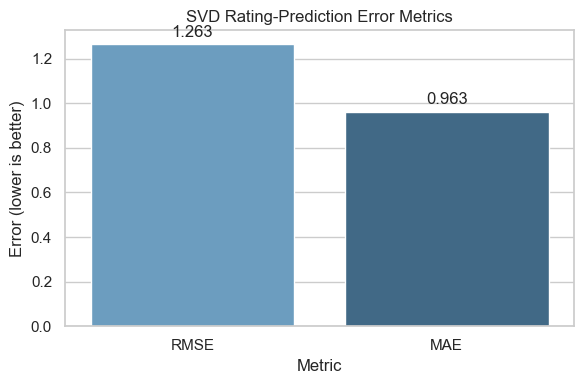

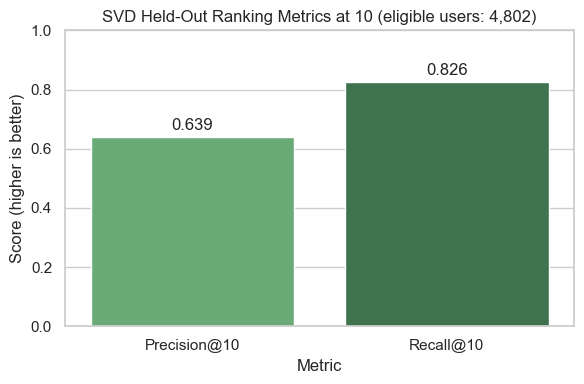

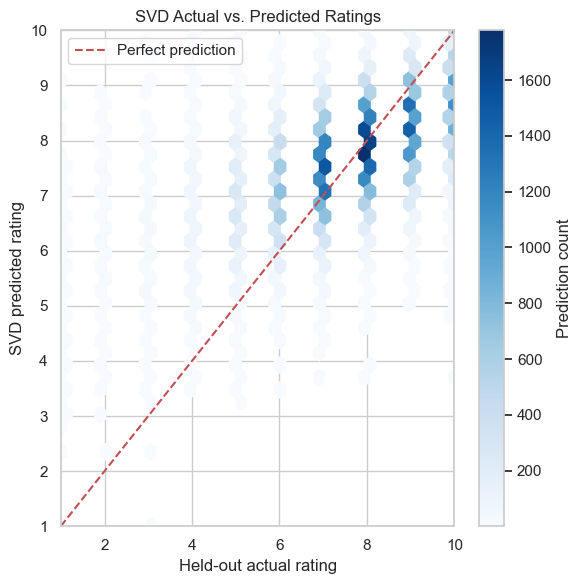

WindowsPath('C:/Users/Quoc/Desktop/DTU/ML Large Data/Anime Recommend/outputs/figures/svd_actual_vs_predicted.png')

In [13]:
error_plot = pd.DataFrame({"Metric": ["RMSE", "MAE"], "Value": [rmse, mae]})
plt.figure(figsize=(6, 4))
axis = sns.barplot(data=error_plot, x="Metric", y="Value", hue="Metric", legend=False, palette="Blues_d")
axis.set(title="SVD Rating-Prediction Error Metrics", ylabel="Error (lower is better)")
for container in axis.containers: axis.bar_label(container, fmt="%.3f", padding=3)
save_figure("svd_error_metrics.png")

ranking_plot = pd.DataFrame({"Metric": [f"Precision@{K}", f"Recall@{K}"], "Value": [precision_at_k, recall_at_k]})
plt.figure(figsize=(6, 4))
axis = sns.barplot(data=ranking_plot, x="Metric", y="Value", hue="Metric", legend=False, palette="Greens_d")
axis.set(title=f"SVD Held-Out Ranking Metrics at {K} (eligible users: {ranking_results['eligible_users']:,})", ylabel="Score (higher is better)", ylim=(0, 1))
for container in axis.containers: axis.bar_label(container, fmt="%.3f", padding=3)
save_figure("svd_ranking_metrics_at_10.png")

scatter_data = prediction_df.sample(n=min(50_000, len(prediction_df)), random_state=SEED)
plt.figure(figsize=(6, 6))
plt.hexbin(scatter_data.true_rating, scatter_data.predicted_rating, gridsize=35, cmap="Blues", mincnt=1)
plt.colorbar(label="Prediction count")
plt.plot([RATING_MIN, RATING_MAX], [RATING_MIN, RATING_MAX], "r--", label="Perfect prediction")
plt.xlim(RATING_MIN, RATING_MAX); plt.ylim(RATING_MIN, RATING_MAX)
plt.xlabel("Held-out actual rating"); plt.ylabel("SVD predicted rating")
plt.title("SVD Actual vs. Predicted Ratings"); plt.legend()
save_figure("svd_actual_vs_predicted.png")

## Generate Top-10 Recommendations

## From Evaluation Model to Recommendations

The outer-split model is retained only for honest metrics. A new model is fitted on all ratings_model interactions for final Top-10 serving. Candidates are anime represented in model data that a selected user has not rated, preventing already-rated recommendations.

Fit the separate serving model on all post-sample/post-filter ratings without replacing the outer-test metric results.

In [14]:
final_data = Dataset.load_from_df(ratings_model[["user_id", "anime_id", "rating"]], reader)
final_trainset = final_data.build_full_trainset()
final_model = SVD(**selected_config).fit(final_trainset)
all_model_anime_ids = set(ratings_model.anime_id)
user_rated_anime = ratings_model.groupby("user_id").anime_id.agg(set).to_dict()
print(f"Serving model fitted on {final_trainset.n_ratings:,} model ratings.")

Serving model fitted on 952,497 model ratings.


## How to Interpret the Recommendation Table

rank is the deterministic position, and predicted_rating is the model's estimated preference on the 1--10 scale. It is not a verified future rating, objective quality score, or public average rating. Metadata is context only.

When EXAMPLE_USER_IDS is None, the notebook chooses seven distinct, reproducible scenarios from observed history: limited history, developing history, typical history, very active, highly positive, more critical, and broad genre exposure. These labels describe only the user's known ratings before recommendation; they do not identify SVD latent factors or guarantee a future preference. Supplying EXAMPLE_USER_IDS overrides this scenario selection.

Score all unseen model candidates, join metadata after ranking, use title and genre fallbacks, and export the exact required column order. A compact profile table and one Top-10 table per scenario make the different recommendation contexts easy to compare in a presentation.

In [15]:
user_profiles = ratings_model.groupby("user_id").agg(
    model_ratings=("rating", "size"),
    mean_observed_rating=("rating", "mean"),
    median_observed_rating=("rating", "median"),
).reset_index()
user_profiles["user_id"] = user_profiles["user_id"].astype(str)

rating_metadata = ratings_model[["user_id", "anime_id"]].merge(
    anime_clean[["anime_id", "genre"]], on="anime_id", how="left"
)
genre_tags = (
    rating_metadata.assign(genre=rating_metadata.genre.fillna("Unknown").astype(str).str.split(","))
    .explode("genre")
    .assign(genre=lambda frame: frame.genre.str.strip())
)
genre_diversity = genre_tags.groupby("user_id").genre.nunique().rename("observed_genre_count")
user_profiles = user_profiles.merge(genre_diversity, on="user_id", how="left")
user_profiles["observed_genre_count"] = user_profiles.observed_genre_count.fillna(0).astype(int)

def first_unused(candidates, scenario, used_user_ids):
    for user_id in candidates.astype(str):
        if user_id not in used_user_ids:
            used_user_ids.add(user_id)
            return {"scenario": scenario, "user_id": user_id}
    return None

if EXAMPLE_USER_IDS is None:
    eligible_profiles = user_profiles[user_profiles.model_ratings >= MIN_RATINGS_FOR_EXAMPLE_USER].copy()
    if len(eligible_profiles) < N_EXAMPLE_USERS:
        raise ValueError(f"Need at least {N_EXAMPLE_USERS} users with {MIN_RATINGS_FOR_EXAMPLE_USER} ratings for the demonstration.")
    typical_count = eligible_profiles.model_ratings.median()
    global_mean = ratings_model.rating.mean()
    scenarios = [
        ("Limited history", user_profiles.query("model_ratings >= 5 and model_ratings < 10").sort_values(["model_ratings", "user_id"])),
        ("Developing history", user_profiles.query("model_ratings >= 10 and model_ratings < @MIN_RATINGS_FOR_EXAMPLE_USER").sort_values(["model_ratings", "user_id"])),
        ("Typical history", eligible_profiles.assign(distance=(eligible_profiles.model_ratings - typical_count).abs(), mean_distance=(eligible_profiles.mean_observed_rating - global_mean).abs()).sort_values(["distance", "mean_distance", "user_id"])),
        ("Very active", eligible_profiles.sort_values(["model_ratings", "user_id"], ascending=[False, True])),
        ("Highly positive", eligible_profiles.sort_values(["mean_observed_rating", "model_ratings", "user_id"], ascending=[False, False, True])),
        ("More critical", eligible_profiles.sort_values(["mean_observed_rating", "model_ratings", "user_id"], ascending=[True, False, True])),
        ("Broad genre exposure", eligible_profiles.sort_values(["observed_genre_count", "model_ratings", "user_id"], ascending=[False, False, True])),
    ]
    used_user_ids, scenario_rows = set(), []
    for scenario, candidates in scenarios:
        selected = first_unused(candidates.user_id, scenario, used_user_ids)
        if selected is None:
            selected = first_unused(eligible_profiles.sort_values("user_id").user_id, f"{scenario} (fallback)", used_user_ids)
        scenario_rows.append(selected)
    selected_scenarios = pd.DataFrame(scenario_rows)
else:
    selected_user_ids = [str(user_id) for user_id in EXAMPLE_USER_IDS]
    missing_users = sorted(set(selected_user_ids) - set(user_profiles.user_id))
    if missing_users:
        raise ValueError(f"EXAMPLE_USER_IDS contains absent users: {missing_users}")
    selected_scenarios = pd.DataFrame({"scenario": [f"Manual example {index}" for index in range(1, len(selected_user_ids) + 1)], "user_id": selected_user_ids})

selected_user_ids = selected_scenarios.user_id.tolist()
scenario_summary = selected_scenarios.merge(user_profiles, on="user_id", how="left")
display(scenario_summary[["scenario", "user_id", "model_ratings", "mean_observed_rating", "median_observed_rating", "observed_genre_count"]].round({"mean_observed_rating": 2, "median_observed_rating": 2}))

rows = []
for user_id in selected_user_ids:
    scored = [(anime_id, float(final_model.predict(user_id, anime_id).est)) for anime_id in sorted(all_model_anime_ids - user_rated_anime[user_id])]
    best = sorted(scored, key=lambda row: (-row[1], row[0]))[:K]
    if len(best) != K: raise ValueError(f"User {user_id} has fewer than {K} unseen model candidates.")
    rows.extend({"user_id": user_id, "rank": rank, "anime_id": anime_id, "predicted_rating": estimate} for rank, (anime_id, estimate) in enumerate(best, 1))

recommendations_df = pd.DataFrame(rows).merge(metadata_for_display(anime_clean), on="anime_id", how="left", validate="many_to_one")
recommendations_df["name"] = recommendations_df.apply(lambda row: row["name"] if pd.notna(row["name"]) and str(row["name"]).strip() else f"Unknown title (ID: {row['anime_id']})", axis=1)
recommendations_df["genre"] = recommendations_df.genre.fillna("Unknown").replace("", "Unknown")
export_columns = ["user_id", "rank", "anime_id", "name", "genre", "type", "episodes", "anime_average_rating", "members", "predicted_rating"]
recommendations_df = recommendations_df[export_columns].sort_values(["user_id", "rank"]).reset_index(drop=True)
per_user_rows = recommendations_df.groupby("user_id").size()
assert per_user_rows.eq(K).all(), "Every exported user must have ten recommendations."
assert recommendations_df.groupby("user_id")["rank"].apply(lambda x: sorted(x.tolist()) == list(range(1, K + 1))).all(), "Ranks must run from 1 through 10."
assert not recommendations_df.duplicated(["user_id", "anime_id"]).any(), "A user cannot receive duplicate anime recommendations."
assert all(anime_id not in user_rated_anime[user_id] for user_id, anime_id in recommendations_df[["user_id", "anime_id"]].itertuples(index=False)), "Recommendations must be unseen in ratings_model."
RECOMMENDATIONS_PATH = OUTPUTS_DIR / "top_10_recommendations.csv"
recommendations_df.to_csv(RECOMMENDATIONS_PATH, index=False, encoding="utf-8")
for scenario, user_id in selected_scenarios.itertuples(index=False):
    print(f"{scenario} scenario — user {user_id}")
    display(recommendations_df.loc[recommendations_df.user_id == user_id, ["rank", "name", "genre", "type", "anime_average_rating", "predicted_rating"]])
print(f"Exported {len(recommendations_df):,} recommendations to {RECOMMENDATIONS_PATH}")

,scenario,user_id,model_ratings,mean_observed_rating,median_observed_rating,observed_genre_count
0,Limited history,10004,5,8.00,8.0,10
1,Developing history,10060,10,7.70,8.0,18
2,Typical history,25321,33,7.79,8.0,30
3,Very active,42635,513,6.38,6.0,43
4,Highly positive,45649,121,10.00,10.0,30
5,More critical,24323,45,1.60,1.0,31
6,Broad genre exposure,65836,255,6.26,6.0,43


Limited history scenario — user 10004


,rank,name,genre,type,anime_average_rating,predicted_rating
0,1,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,9.11,9.807743
1,2,Gintama,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.04,9.664618
2,3,Aria The Origination,"Fantasy, Sci-Fi, Shounen, Slice of Life",TV,8.64,9.611416
3,4,Gintama&#039;: Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.11,9.603826
4,5,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,9.1,9.599335
5,6,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,8.54,9.573768
6,7,Katanagatari,"Action, Adventure, Historical, Martial Arts, R...",TV,8.49,9.556762
7,8,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.25,9.539535
8,9,Rainbow: Nisha Rokubou no Shichinin,"Drama, Historical, Seinen, Thriller",TV,8.64,9.519311
9,10,Mushishi Zoku Shou 2nd Season,"Adventure, Fantasy, Historical, Mystery, Seine...",TV,8.88,9.490488


Developing history scenario — user 10060


,rank,name,genre,type,anime_average_rating,predicted_rating
10,1,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,9.11,10.000000
11,2,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,9.37,9.646204
12,3,Tengen Toppa Gurren Lagann,"Action, Adventure, Comedy, Mecha, Sci-Fi",TV,8.78,9.608239
13,4,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.25,9.600402
14,5,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,9.1,9.554913
15,6,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.16,9.497525
16,7,Mushishi,"Adventure, Fantasy, Historical, Mystery, Seine...",TV,8.78,9.383699
17,8,Gintama&#039;: Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.11,9.366258
18,9,Neon Genesis Evangelion: The End of Evangelion,"Dementia, Drama, Mecha, Psychological, Sci-Fi",Movie,8.45,9.355273
19,10,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.26,9.326275


...

More critical scenario — user 24323


,rank,name,genre,type,anime_average_rating,predicted_rating
20,1,Mobile Suit Gundam Seed Destiny,"Action, Drama, Mecha, Military, Romance, Sci-F...",TV,7.36,5.414856
21,2,Sen to Chihiro no Kamikakushi,"Adventure, Drama, Supernatural",Movie,8.93,4.767389
22,3,Clannad: After Story,"Drama, Fantasy, Romance, Slice of Life, Supern...",TV,9.06,4.583811
23,4,Naruto: Shippuuden Movie 2 - Kizuna,"Action, Martial Arts, Shounen, Supernatural",Movie,7.43,4.543082
24,5,Mobile Suit Gundam Seed,"Action, Drama, Mecha, Military, Romance, Sci-F...",TV,7.93,4.471213
25,6,Watashi ga Motenai no wa Dou Kangaetemo Omaera...,"Comedy, School, Shounen, Slice of Life",TV,7.29,4.470953
26,7,Shinsekai yori,"Drama, Horror, Mystery, Sci-Fi, Supernatural",TV,8.53,4.467673
27,8,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",TV,8.22,4.398856
28,9,Gungrave,"Action, Drama, Sci-Fi, Seinen, Super Power",TV,7.97,4.351581
29,10,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,9.11,4.340632


Broad genre exposure scenario — user 65836


,rank,name,genre,type,anime_average_rating,predicted_rating
60,1,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,8.82,10.000000
61,2,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,8.71,10.000000
62,3,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,9.11,9.467631
63,4,Shinsekai yori,"Drama, Horror, Mystery, Sci-Fi, Supernatural",TV,8.53,9.424186
64,5,Steins;Gate,"Sci-Fi, Thriller",TV,9.17,9.412182
65,6,Mushishi,"Adventure, Fantasy, Historical, Mystery, Seine...",TV,8.78,9.266579
66,7,Hajime no Ippo,"Comedy, Drama, Shounen, Sports",TV,8.83,9.137492
67,8,Clannad: After Story,"Drama, Fantasy, Romance, Slice of Life, Supern...",TV,9.06,9.089900
68,9,Tengen Toppa Gurren Lagann,"Action, Adventure, Comedy, Mecha, Sci-Fi",TV,8.78,9.054248
69,10,Ping Pong The Animation,"Psychological, Seinen, Sports",TV,8.67,9.000395


Exported 70 recommendations to C:\Users\Quoc\Desktop\DTU\ML Large Data\Anime Recommend\outputs\top_10_recommendations.csv


## Conclusion, Limitations, and Reproducibility

The result summary is produced from runtime variables, not hard-coded Markdown, and is the source for reporting this exact run.

Print the post-filter model-data size, configuration, metrics, eligible users, and output paths.

In [16]:
model_summary = matrix_summary(ratings_model, "Final model data").iloc[0]
print("\n".join([
    f"- Model data: {int(model_summary.interactions):,} interactions, {int(model_summary.users):,} users, and {int(model_summary.anime):,} anime after sampling and k-core filtering.",
    f"- Selected SVD configuration: {selected_config}.",
    f"- Outer-holdout RMSE: {rmse:.4f}; MAE: {mae:.4f}.",
    f"- Held-out observed-item Precision@{K}: {precision_at_k:.4f}; Recall@{K}: {recall_at_k:.4f}.",
    f"- Eligible ranking users: {ranking_results['eligible_users']:,} of {ranking_results['total_test_users']:,} test users.",
    f"- Demonstration scenarios: {', '.join(selected_scenarios.scenario.tolist())}.",
    f"- Outputs: {RECOMMENDATIONS_PATH}, {METRICS_PATH}, and {FIGURES_DIR}.",
]))

- Model data: 952,497 interactions, 41,370 users, and 5,985 anime after sampling and k-core filtering.
- Selected SVD configuration: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.02, 'random_state': 42}.
- Outer-holdout RMSE: 1.2632; MAE: 0.9625.
- Held-out observed-item Precision@10: 0.6386; Recall@10: 0.8255.
- Eligible ranking users: 4,802 of 37,748 test users.
- Demonstration scenarios: Limited history, Developing history, Typical history, Very active, Highly positive, More critical, Broad genre exposure.
- Outputs: C:\Users\Quoc\Desktop\DTU\ML Large Data\Anime Recommend\outputs\top_10_recommendations.csv, C:\Users\Quoc\Desktop\DTU\ML Large Data\Anime Recommend\outputs\model_evaluation_metrics.csv, and C:\Users\Quoc\Desktop\DTU\ML Large Data\Anime Recommend\outputs\figures.


## Reading the Results Responsibly

Compare metrics only under the same split and data scope. Report eligible-user counts with ranking metrics. Do not call sampled/k-core data the whole dataset, and do not infer causal preferences from latent factors.

## Limitations and Future Work

- SVD does not solve cold-start users/anime with no or few ratings; a genre-based metadata fallback could help.
- Explicit ratings exclude watched-but-unrated -1 interactions, and sampling/k-core filtering can bias coverage toward active users/anime.
- Precision/Recall use observed holdout ratings and may not represent full-catalog ranking.
- Future work: lightweight validation/tuning, a temporal split when timestamps exist, hybrid genre recommendations, and catalog evaluation with documented negative sampling.

The final checklist verifies all required artifacts and prints the rerun command.

In [17]:
required_columns = ["user_id", "rank", "anime_id", "name", "genre", "type", "episodes", "anime_average_rating", "members", "predicted_rating"]
checklist = pd.DataFrame([
    {"check": "Input files are present", "passed": RATINGS_PATH.exists() and ANIME_PATH.exists()},
    {"check": "Model data is valid and non-empty", "passed": not ratings_model.empty and ratings_model.rating.between(RATING_MIN, RATING_MAX).all()},
    {"check": "All four metrics are finite", "passed": np.isfinite([rmse, mae, precision_at_k, recall_at_k]).all()},
    {"check": "Recommendation CSV has the required schema", "passed": list(pd.read_csv(RECOMMENDATIONS_PATH, nrows=0).columns) == required_columns},
    {"check": "Ten recommendations exist for every selected user", "passed": per_user_rows.eq(K).all()},
    {"check": "Metrics CSV exists", "passed": METRICS_PATH.exists()},
    {"check": "All three evaluation PNG files exist", "passed": all((FIGURES_DIR / name).exists() for name in ["svd_error_metrics.png", "svd_ranking_metrics_at_10.png", "svd_actual_vs_predicted.png"])},
])
checklist["status"] = np.where(checklist.passed, "PASS", "FAIL")
display(checklist[["status", "check"]])
assert checklist.passed.all(), "The final checklist contains a failure."
print("jupyter nbconvert --execute --to notebook --inplace notebooks/02_svd_model_evaluation.ipynb")

,status,check
0,PASS,Input files are present
1,PASS,Model data is valid and non-empty
2,PASS,All four metrics are finite
3,PASS,Recommendation CSV has the required schema
4,PASS,Ten recommendations exist for every selected user
5,PASS,Metrics CSV exists
6,PASS,All three evaluation PNG files exist


jupyter nbconvert --execute --to notebook --inplace notebooks/02_svd_model_evaluation.ipynb
